# Mi primera simulación del LHC en Pythia 🚀
Author: A. Ramirez-Morales (andres.ramirez.morales@cern.ch)

## Instrucciones:
- Lea cuidadosamente las explicaciones
- Comente las líneas de código donde se indique explicando claro y breve la función de dicha línea
- Resolver los ejercicios al final del Notebook
- Consulte la página oficial de Pythia8: https://pythia.org/




## Primero, instalemos Pythia en nuestro entorno

In [ ]:
# ejecuta esta celta con el botón de play de la izquierda
!pip install pythia8mc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.6/29.6 MB 52.0 MB/s eta 0:00:00


# ¿Qué es Pythia?

Pythia es un generador de eventos para física de partículas. Es un programa de computadora que simula colisiones de partículas (como las que ocurren en el LHC del CERN) y predice qué partículas se producirán y cómo se moverán.

# ¿Para qué sirve?
Queremos estudiar colisiones de partículas pero:

- No tienes acceso a un acelerador (cuestan miles de millones de euros 🤡)
- No puedes hacer un experimento cada vez que tienes una idea nueva
- Necesitas comparar tus teorías con datos reales

Nos falta aura!! **Solución:** Usar Pythia para simular las colisiones en la computadora. Pythia es un simulador de eventos **Monte Carlo** [https://aws.amazon.com/es/what-is/monte-carlo-simulation/]



# Paso 1: Cargar las librerías necesarias

In [ ]:
# ejecute esta celda para cargar las librerías
import pythia8mc
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib import rcParams
import math

# Configuración de gráficos
rcParams['font.size'] = 12
sns.set_style("whitegrid")

# Paso 2: Configurar con las opciones de Pythia
El proceso que vamos a simular es $pp→Z→e^-e^+$, es decir la **colisión** de dos protones, que despues **producen** un bosón Z y este bosón **decae** a un electrón y un positrón, todo dentro del LHC
### Antes de revisar el código, respondamos las siguientes preguntas:
- ¿A qué energía colisionan los protones en el LHC?
Una colision proton-proton se trabaja a una energia de centro de masa de aproximadamente 13.6 TeV
- ¿Cuál es la masa experimental del bosón Z? Aproximadamente 91.1876 GeV/c^2
- ¿Qué significa `pdgID` o número de partícula en simulaciones Monte Carlo? (Particule Data Group identifier) es un numero entero usado para identificar el tipo de particula en programas como pythia, geant4 y anchivos de eventos Monte Carlo. No es el numero de orden de la particula dentro del evento.

In [ ]:
# ejecute esta celda, y comente las lineas indicadas procurando dar una explicacion

# Crear el generador de eventos PYTHIA
pythia = pythia8mc.Pythia()

# Definir el haz A como protones (PDG ID del protón = 2212)
pythia.readString("Beams:idA = 2212")

# Definir el haz B como protones
pythia.readString("Beams:idB = 2212")

# Establecer la energía de centro de masa en 14 GeV
pythia.readString("Beams:eCM = 14000")

# activar nuestro proceso de interés
pythia.readString("WeakSingleBoson:ffbar2gmZ = on")

# inicializar Pythia
pythia.init()

True

# Paso 3: Hacer la simulación

### Queremos entender como funciona Pythia hace la simulación de eventos, para ello, debemos plantearnos las siguientes preguntas:

- En Pythia, ¿qué significa un evento(`event`)? Es una colision simulada completa. Contiene el regisro de todas las etapas que pythia genero: particulas iniciales, patrones que interactuan, particulas intermedias como 'Z', productos de decaimiento, radiacion, ionizacion, hadrinizacion y particulas finales estables. En codigo, pythia. event es basicamente la lista de particulas pertenecientes a ese evento.
- En Pythia, qué significa una partícula (`particle`)? Es una entrada individual dentro del evento. Cada particle contiene informacion como su PDG ID, estado, momento, energia, masa y relaciones con otras particulas.
- Aquí, ¿que significa madre (`mother`), hija (`daughter`)? Describen la historia de produccion y decaimiento de las particulas. Una madre es la particula de la cual se origino otra; una hija es una particula producida a partir de otra
- ¿Qué unidades de masa, momento y energía se adoptan en Pythia? Utiliza principalmente GeV y adopta unidades naturales como c=\hbar=1. E:GeV, p:GeV/c, m:GeV/c^2
- ¿Qué es lo que nos interesa almacenar después de que terminamos la simulación? No necesitamos guardar absolutamente todas las particulas de todos los eventos. Guardamos la informacion necesaria para nuestro analisis, como cantidades observables que podamos comparar con la fisica real.

In [ ]:
# Ejecute el código de esta celda y agregue comentarios donde se indique

# aqui preparamos las variables donde almacenaremos la información de interés

# electron
pT_e = []   #guardara el momento transversal del electron

# positron
pT_pos = []   #guardara el momento transversal de los electrones

# bosón Z: Guardaremos su masa reconstruida, su masa original en PYTHIA y su momento transversal
reconstructed_Z_masses = []
z_mass_og = []
z_pt_og = []


# generate events
n_events = 10000
for i in range(n_events):
    if not pythia.next():
        continue
    z_boson_found = False
    for particle in pythia.event:
        if particle.id() == 23:  # Z boson
            # check if the Z boson mass is within a certain range
            z_mass = particle.m()
            if abs(z_mass - 91.1876) < 10.0:  #Seleccionamos unicamente bosones Z cuya masa este a menos de 10GeV de la masa experimental del Z.
                z_boson_found = True
                mass_z = particle.p().mCalc()
                break # Ya encontramos un boson Z que satisface nuestra condicion, por lo que dejamos de buscar mas Z dentro del evento.

    if not z_boson_found:
        continue
    electrons_found = []
    positrons_found = []
    for i in range(pythia.event.size()):
        particle = pythia.event[i]
        if particle.id() == 11:  # electron
            mother = particle.mother1()
            if pythia.event[mother].id() == 23:  # Comprobamos que la particula madre sea un bozon Z (ID 23). De esta forma seleccionamos e producidos por un decaimiento de Z
                electrons_found.append(particle)
        elif particle.id() == -11:  # positron
            mother = particle.mother1()
            if pythia.event[mother].id() == 23:  # Igual que arriba, pero para positrones
                positrons_found.append(particle)

    # Probamos las combinaciones electron-positron encontradas para identificar parejas que vengan del mismo boson Z.
    for electron in electrons_found:
        for positron in positrons_found:
            if electron.mother1() == positron.mother1(): # Verificamos que ambos tengan el mismo indice de particula madre: es decir, que ambos provengan del decaimiento del mismo boson Z.
                # get electron kinematics
                pElectron = electron.p() # Obtenemos el cuadrimimento del electron (E,px, py, pz)
                pT_e.append(pElectron.pT()) # Calculamos y almacenamos el momento transversal del electron pT = sqrt(px^2 + py^2)

                # get positron kinematics
                pPositron = positron.p()
                pT_pos.append(pPositron.pT())

                # Z boson kinematics
                reconstructed_Z_mass = (pElectron + pPositron).mCalc()
                reconstructed_Z_masses.append(reconstructed_Z_mass)
                z_mass_og.append(mass_z)
                z_pt_og.append((pElectron + pPositron).pT())

# Paso 4: Graficar y analizar resultados

Text(0, 0.5, 'Eventos')

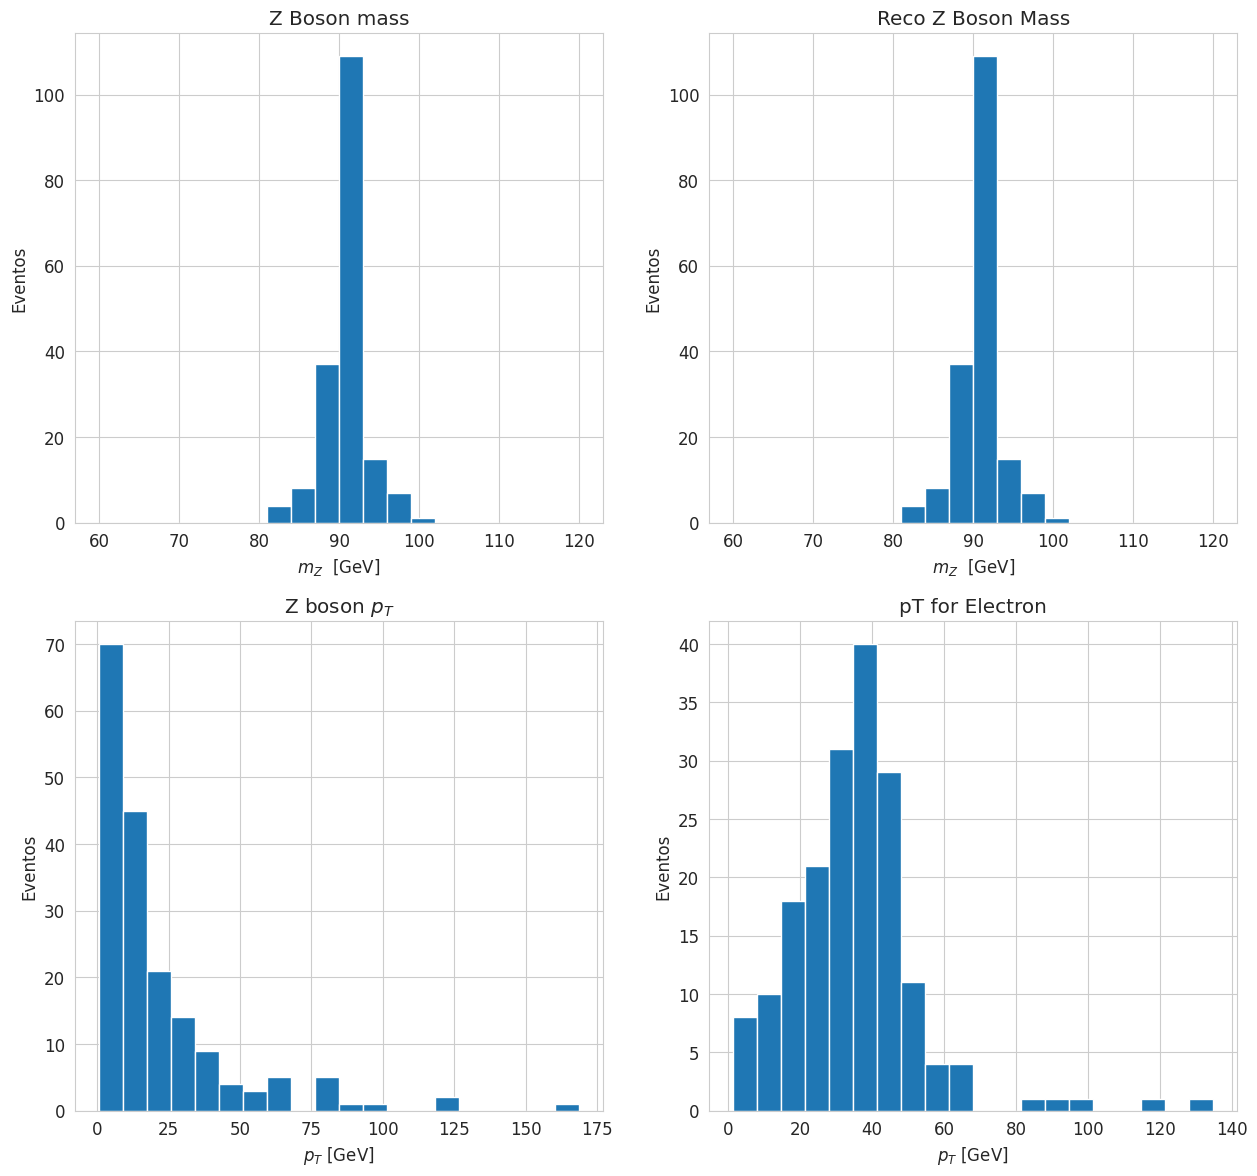

In [ ]:
# ejecute esta celda para ver los histogramas resultantes de los datos que acaba de generar
fig, axs = plt.subplots(2, 2, figsize=(15, 14), subplot_kw={'aspect': 'auto'})

hist_mass_Z, bins_mass_Z, _ = axs[0, 0].hist(z_mass_og, bins=20, range=(60, 120))
axs[0, 0].set_title('Z Boson mass')
axs[0, 0].set_xlabel('$m_Z$  [GeV]')
axs[0, 0].set_ylabel('Eventos')

# histogram of reconstructed Z boson mass
hist_reco_Z_mass, bins_reco_Z_mass, _ = axs[0, 1].hist(reconstructed_Z_masses, bins=20, range=(60, 120)) #, histtype='step')
axs[0, 1].set_xlabel('$m_Z$  [GeV]')
axs[0, 1].set_ylabel('Eventos')
axs[0, 1].set_title('Reco Z Boson Mass')

# histogram of z pt
hist_pt_z, bins_pt_z, _ = axs[1, 0].hist(z_pt_og, bins=20)#, range=(60, 120))
axs[1, 0].set_xlabel('$p_T$ [GeV]')
axs[1, 0].set_ylabel('Eventos')
axs[1, 0].set_title('Z boson $p_T$')

# electron variables
#  pt for Electron
hist_pt_e, bins_pt_e, _ = axs[1, 1].hist(pT_e, bins=20)
axs[1, 1].set_title('pT for Electron')
axs[1, 1].set_xlabel('$p_T$ [GeV]')
axs[1, 1].set_ylabel('Eventos')


# Ejercicios

- Dibujar el diagrama de Feynman a nivel de árbol para este proceso
- Cambiar la simulación para que en lugar de colisionar protones, colisione electrón VS positrón
- Investigar y agregar más variables cinemáticas de interés en experimentos de física de altas energías
- Reproduzca las condiciones de los futuros colisionadores de partículas (Ejemplo el ILC).
- **Reto:** Modificar la simulación para que en lugar de producir un bosón $Z$ se produzca un bosón cargado $W$

In [ ]:
# Configurar la colisión electrón contra positrón

pythia = pythia8mc.Pythia()

# 11 es el código del electrón
pythia.readString("Beams:idA = 11")

# -11 es el código del positrón
pythia.readString("Beams:idB = -11")

# Energía de la colisión cercana a la masa del bosón Z
pythia.readString("Beams:eCM = 91.1876")

# Activar la producción de un fotón virtual o un bosón Z
pythia.readString("WeakSingleBoson:ffbar2gmZ = on")

# Inicializar Pythia
pythia.init()

True

In [ ]:
# Preparar las listas donde guardaremos los resultados

# Momento transversal del electrón
pT_e = []

# Momento transversal del positrón
pT_pos = []

# Masa reconstruida del bosón Z
reconstructed_Z_masses = []

# Masa original del bosón Z
z_mass_og = []

# Momento transversal del bosón Z
z_pt_og = []


n_events = 10000

for i in range(n_events):

    # Generar un evento
    if not pythia.next():
        continue

    # Buscar un bosón Z en el evento
    z_boson_found = False

    for particle in pythia.event:

        # El código 23 corresponde al bosón Z
        if particle.id() == 23:

            # Obtener la masa del bosón Z
            z_mass = particle.m()

            # Seleccionar bosones con masa cercana a 91.1876 GeV
            if abs(z_mass - 91.1876) < 10.0:

                z_boson_found = True
                mass_z = particle.p().mCalc()
                break

    # Si no se encontró un bosón Z, pasar al siguiente evento
    if not z_boson_found:
        continue

    # Listas para guardar los electrones y positrones del evento
    electrons_found = []
    positrons_found = []

    # Recorrer todas las partículas del evento
    for j in range(pythia.event.size()):

        particle = pythia.event[j]

        # Buscar electrones
        if particle.id() == 11:

            # Obtener la partícula madre del electrón
            mother = particle.mother1()

            # Verificar que el electrón venga de un bosón Z
            if pythia.event[mother].id() == 23:
                electrons_found.append(particle)

        # Buscar positrones
        elif particle.id() == -11:

            # Obtener la partícula madre del positrón
            mother = particle.mother1()

            # Verificar que el positrón venga de un bosón Z
            if pythia.event[mother].id() == 23:
                positrons_found.append(particle)

    # Combinar los electrones y positrones encontrados
    for electron in electrons_found:

        for positron in positrons_found:

            # Verificar que ambos provengan del mismo bosón Z
            if electron.mother1() == positron.mother1():

                # Obtener el momento del electrón
                pElectron = electron.p()

                # Guardar el momento transversal del electrón
                pT_e.append(pElectron.pT())

                # Obtener el momento del positrón
                pPositron = positron.p()

                # Guardar el momento transversal del positrón
                pT_pos.append(pPositron.pT())

                # Reconstruir la masa del bosón Z
                reconstructed_Z_mass = (
                    pElectron + pPositron
                ).mCalc()

                # Guardar los resultados
                reconstructed_Z_masses.append(
                    reconstructed_Z_mass
                )

                z_mass_og.append(mass_z)

                z_pt_og.append(
                    (pElectron + pPositron).pT()
                )

Text(0, 0.5, 'Eventos')

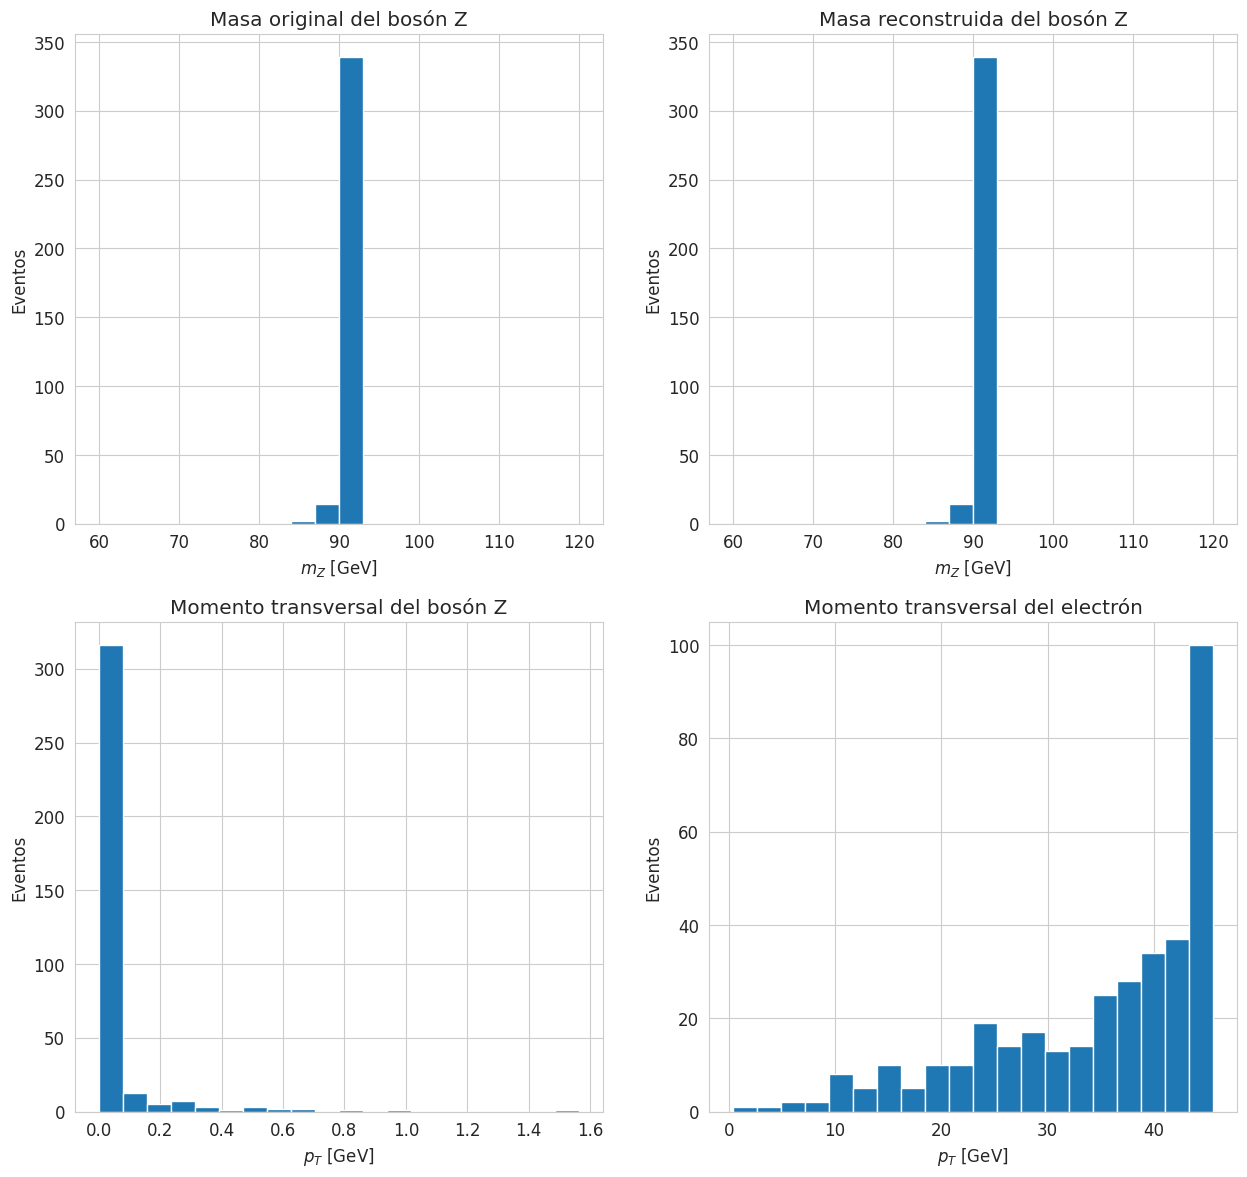

In [ ]:
# Crear el área para las cuatro gráficas

fig, axs = plt.subplots(
    2,
    2,
    figsize=(15, 14),
    subplot_kw={'aspect': 'auto'}
)


# Masa original del bosón Z
axs[0, 0].hist(
    z_mass_og,
    bins=20,
    range=(60, 120)
)

axs[0, 0].set_title('Masa original del bosón Z')
axs[0, 0].set_xlabel('$m_Z$ [GeV]')
axs[0, 0].set_ylabel('Eventos')


# Masa reconstruida del bosón Z
axs[0, 1].hist(
    reconstructed_Z_masses,
    bins=20,
    range=(60, 120)
)

axs[0, 1].set_title('Masa reconstruida del bosón Z')
axs[0, 1].set_xlabel('$m_Z$ [GeV]')
axs[0, 1].set_ylabel('Eventos')


# Momento transversal del bosón Z
axs[1, 0].hist(
    z_pt_og,
    bins=20
)

axs[1, 0].set_title('Momento transversal del bosón Z')
axs[1, 0].set_xlabel('$p_T$ [GeV]')
axs[1, 0].set_ylabel('Eventos')


# Momento transversal del electrón
axs[1, 1].hist(
    pT_e,
    bins=20
)

axs[1, 1].set_title('Momento transversal del electrón')
axs[1, 1].set_xlabel('$p_T$ [GeV]')
axs[1, 1].set_ylabel('Eventos')

Usaremos una version sencilla del ILC: Colisiones electron vs positron a 250 GeV. Esa energia corresponde a la etapa propuesta como fabrica de Higgs del ILC.

Agregamos tres variables nuevas:
- Energia E.
- pseudo rapidez η, que indica que tan central o cercana al haz viaja la particula.
- Angulo azimutal 𝛟, medido al rededor del eje del haz.

In [ ]:
# Crear la simulación del ILC
pythia = pythia8mc.Pythia()

# Primer haz: electrones
pythia.readString("Beams:idA = 11")

# Segundo haz: positrones
pythia.readString("Beams:idB = -11")

# Energía del centro de masa del ILC
pythia.readString("Beams:eCM = 250")

# Usar el mismo proceso del notebook
pythia.readString("WeakSingleBoson:ffbar2gmZ = on")

# Inicializar Pythia
pythia.init()

True

In [ ]:
# Variables del electrón
pT_e = []
energia_e = []
eta_e = []
phi_e = []

# Variables del positrón
pT_pos = []
energia_pos = []
eta_pos = []
phi_pos = []

# Variables del sistema electrón-positrón
reconstructed_Z_masses = []
z_mass_og = []
z_pt_og = []


# Número de eventos
n_events = 5000

for i in range(n_events):

    # Generar un evento
    if not pythia.next():
        continue

    # Buscar el fotón virtual o bosón Z
    z_boson_found = False

    for particle in pythia.event:

        # Pythia usa el código 23 para el sistema fotón virtual/Z
        if particle.id() == 23:

            z_boson_found = True
            mass_z = particle.p().mCalc()
            break

    # Si no se encontró, continuar con el siguiente evento
    if not z_boson_found:
        continue

    # Buscar electrones y positrones
    electrons_found = []
    positrons_found = []

    for j in range(pythia.event.size()):

        particle = pythia.event[j]

        # Buscar electrones provenientes del Z
        if particle.id() == 11:

            mother = particle.mother1()

            if pythia.event[mother].id() == 23:
                electrons_found.append(particle)

        # Buscar positrones provenientes del Z
        elif particle.id() == -11:

            mother = particle.mother1()

            if pythia.event[mother].id() == 23:
                positrons_found.append(particle)

    # Combinar los electrones y positrones
    for electron in electrons_found:

        for positron in positrons_found:

            # Verificar que provengan de la misma partícula madre
            if electron.mother1() == positron.mother1():

                # Obtener los cuatro-momentos
                pElectron = electron.p()
                pPositron = positron.p()

                # Momento transversal
                pT_e.append(pElectron.pT())
                pT_pos.append(pPositron.pT())

                # Energía
                energia_e.append(pElectron.e())
                energia_pos.append(pPositron.e())

                # Pseudorapidez
                eta_e.append(pElectron.eta())
                eta_pos.append(pPositron.eta())

                # Ángulo azimutal
                phi_e.append(pElectron.phi())
                phi_pos.append(pPositron.phi())

                # Reconstruir la masa del sistema electrón-positrón
                reconstructed_Z_mass = (
                    pElectron + pPositron
                ).mCalc()

                reconstructed_Z_masses.append(
                    reconstructed_Z_mass
                )

                # Guardar la masa original
                z_mass_og.append(mass_z)

                # Guardar el momento transversal reconstruido
                z_pt_og.append(
                    (pElectron + pPositron).pT()
                )

<>:61: SyntaxWarning: invalid escape sequence '\e'
<>:73: SyntaxWarning: invalid escape sequence '\p'
<>:61: SyntaxWarning: invalid escape sequence '\e'
<>:73: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_1833/2627696721.py:61: SyntaxWarning: invalid escape sequence '\e'
  axs[1, 1].set_xlabel('$\eta$')
/tmp/ipykernel_1833/2627696721.py:73: SyntaxWarning: invalid escape sequence '\p'
  axs[1, 2].set_xlabel('$\phi$ [radianes]')


Text(0, 0.5, 'Eventos')

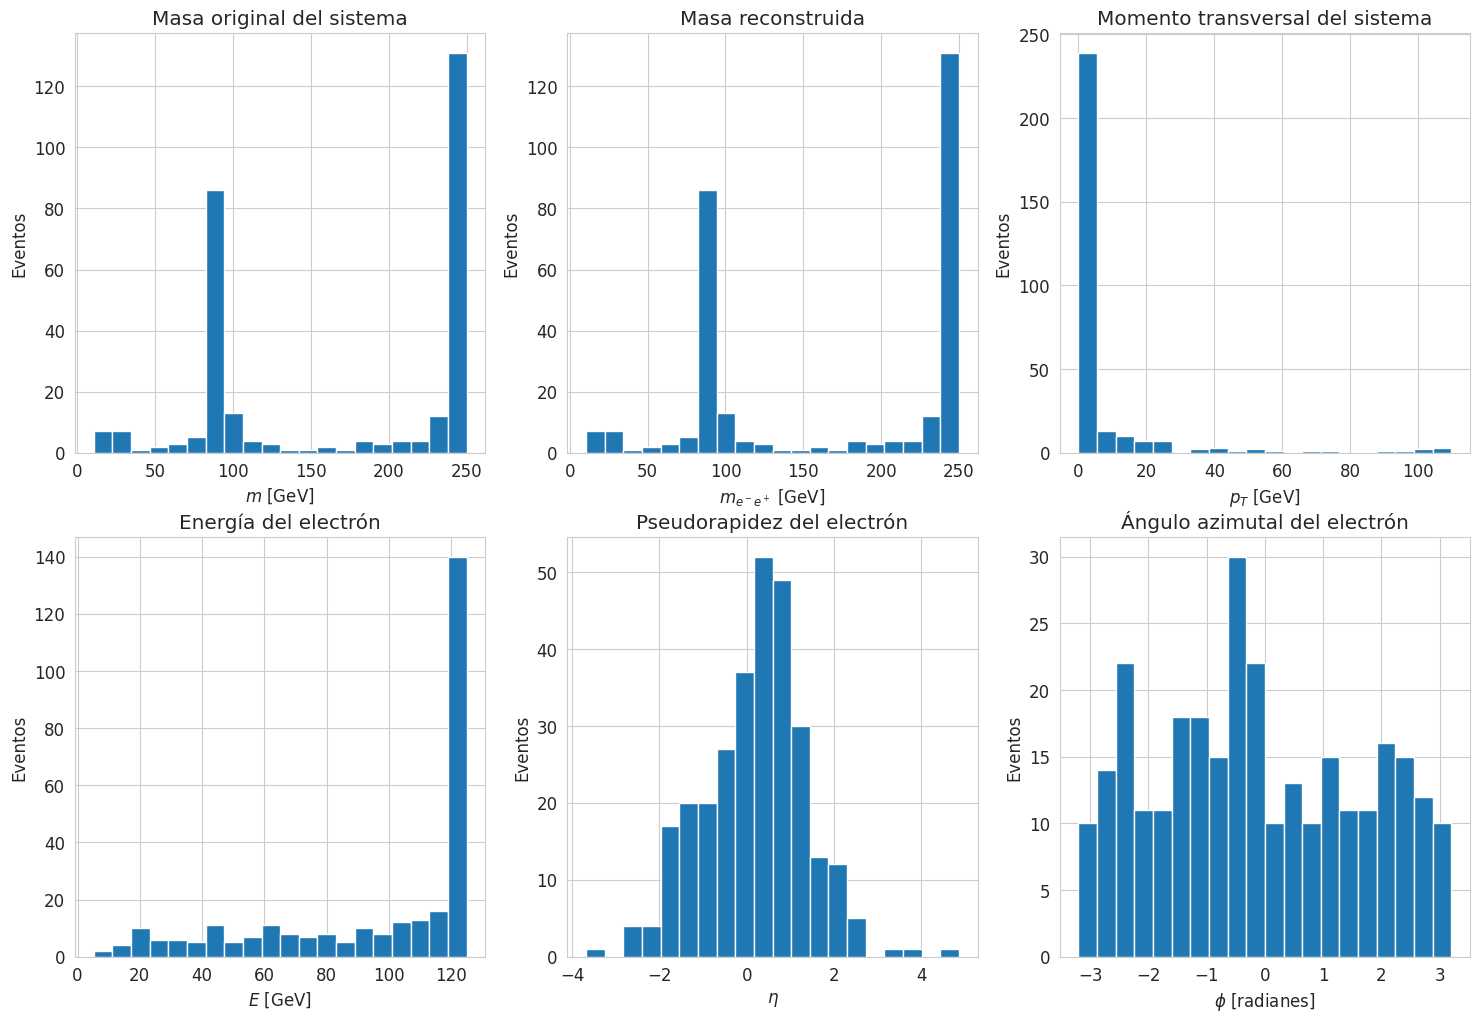

In [ ]:
# Crear seis áreas para las gráficas
fig, axs = plt.subplots(
    2,
    3,
    figsize=(18, 12),
    subplot_kw={'aspect': 'auto'}
)


# Masa original
axs[0, 0].hist(
    z_mass_og,
    bins=20
)

axs[0, 0].set_title('Masa original del sistema')
axs[0, 0].set_xlabel('$m$ [GeV]')
axs[0, 0].set_ylabel('Eventos')


# Masa reconstruida
axs[0, 1].hist(
    reconstructed_Z_masses,
    bins=20
)

axs[0, 1].set_title('Masa reconstruida')
axs[0, 1].set_xlabel('$m_{e^-e^+}$ [GeV]')
axs[0, 1].set_ylabel('Eventos')


# Momento transversal
axs[0, 2].hist(
    z_pt_og,
    bins=20
)

axs[0, 2].set_title('Momento transversal del sistema')
axs[0, 2].set_xlabel('$p_T$ [GeV]')
axs[0, 2].set_ylabel('Eventos')


# Energía del electrón
axs[1, 0].hist(
    energia_e,
    bins=20
)

axs[1, 0].set_title('Energía del electrón')
axs[1, 0].set_xlabel('$E$ [GeV]')
axs[1, 0].set_ylabel('Eventos')


# Pseudorapidez del electrón
axs[1, 1].hist(
    eta_e,
    bins=20
)

axs[1, 1].set_title('Pseudorapidez del electrón')
axs[1, 1].set_xlabel('$\eta$')
axs[1, 1].set_ylabel('Eventos')


# Ángulo azimutal del electrón
axs[1, 2].hist(
    phi_e,
    bins=20,
    range=(-3.2, 3.2)
)

axs[1, 2].set_title('Ángulo azimutal del electrón')
axs[1, 2].set_xlabel('$\phi$ [radianes]')
axs[1, 2].set_ylabel('Eventos')

La simulación reproduce una colisión electrón–positrón a 250 GeV, correspondiente a las condiciones energéticas del ILC. Se estudiaron nuevas variables cinemáticas como la energía, la pseudorapidez y el ángulo azimutal del electrón. La masa reconstruida coincide con la masa original del sistema, y se observan acumulaciones alrededor de 91 GeV y 250 GeV, asociadas respectivamente con la producción resonante del bosón Z y con eventos que aprovechan casi toda la energía del centro de masa.